# Kalpi.ai Assignment



## Web Agent Algorithm

1. Navogate to Kalpi.ai
2. Click on Product Overview -> Strategy Builder

3. Click on Universe Box
	- Select Universe Dropdown
	- Choose a Universe

4. Click on filters box
	- Click on add condition
	- Add operator and number
	- repeat for list of conditions

5. Click on Ranking and Scoring
	- Select what metrics you want for the ranking
	- repeat for items in list

6. Click on weights
	- Enter No of Stocks
	- Select either equal weight or metric weight


Bare minimum needed
Universe
Ranking metric

## Non-Web Algorithm

1. Get user description for strategy
    - Make a detailed implementation based description of the strategy given by the user.

2. Take the detailed report and choose a universe from which to select stocks

3. Make a list of filtration metrics relevant to the strategy
    - assign greater than or less than operator and a comparision value

4. Make a list of metrics on which to score and rank stocks

5. Select the top n no of stocks to put
    - Ask equal or metric weight
    - if metric weight Select metrics for metrics

In [1]:
from typing import TypedDict, Annotated, List, Tuple, Literal, Optional

class FilterCondition(TypedDict):
    metric: str
    operator: Literal["<", ">", "<=", ">=", "=="]
    value: float

class Reasoning(TypedDict):
    universe: str
    filter: str
    rank: str
    weightage: str
    modification: str

In [2]:
universes_constant = ["All Universe", "Nifty 500", 'Nifty 200', "Nifty 100", "Nifty 50", "Nifty Next 50", "Nifty Total Market",
             "Nifty Midcap 150", "Nifty Midcap 100", "Nifty Midcap 50", "Nifty Smallcap 250", "Nifty Smallcap 100",
             "Nifty Smallcap 50", "Nifty Microcap 250", "NIFTY MIDSMALLCAP 400", "Nifty LargeMidcap 250", "NIFTY FNO"]

metrics_constant = [
    "Close Price",
    "High Price",
    "Low Price",
    "Open Price",
    "Volume",
    "ADX 14",
    "ATR 14",
    "Bollinger Bands Lower",
    "Bollinger Bands Middle",
    "Bollinger Bands Upper",
    "CCI 14",
    'Dividend Yield',
    "EMA 100",
    "EMA 10",
    "EMA 15",
    "EMA 20",
    "EMA 200",
    "EMA 5",
    "EMA 50",
    'Market Capitalization',
    "MACD",
    "MACD Histogram",
    "MACD Signal",
    "MFI 14",
    "Momentum 10",
    "OBV",
    "PPO",
    "RSI 14",
    "SMA 100",
    "SMA 10",
    "SMA 15",
    "SMA 20",
    "SMA 200",
    "SMA 5",
    "SMA 50",
    "Stochastic Slow D",
    "Stochastic Slow K",
    "Williams %R 14",
    "WMA 100",
    "WMA 10",
    "WMA 15",
    "WMA 20",
    "WMA 200",
    "WMA 5",
    "WMA 50",
    "EBITDA Q",
    "EBITDA growth QoQ",
    "P/E Ratio",
    "Return 1D",
    "EPS growth QoQ",
    "EPS Q",
    "EPS growth YoY",
    "EPS Prev Q",
    "EPS Prev YQ",
    "EPS FY",
    "EPS FY growth 1Y",
    "EPS FY 3Y CAGR",
    "EPS FY 5Y CAGR",
    "EPS FY 7Y CAGR",
    "EPS FY 10Y CAGR",
    "EPS Last Yr",
    "EPS Prev Yr",
    "EPS TTM",
    "EPS Growth YoY TTM",
    "Volatility 1M",
    "Volatility 3M",
    "Volatility 1Y",
    "Volatility Score",
    "Beta 1Y"
]

In [3]:
import re

def validate_metrics(proposed, available) -> list[str]:
    """
    Keep only metrics whose names exactly match the available list.
    For near-misses (e.g. 'RSI' vs 'RSI 14'), attempt a fuzzy fallback
    so we don't silently drop useful metrics.
    """
    available_set = set(available)
    valid = []
    skipped = []

    for m in proposed:
        if m in available_set:
            valid.append(m)
        else:
            # Case-insensitive exact match
            lower_map = {a.lower(): a for a in available}
            if m.lower() in lower_map:
                valid.append(lower_map[m.lower()])
            else:
                # Prefix match: "RSI" → "RSI 14", "EMA" → "EMA 20" (first hit)
                prefix_hits = [a for a in available if a.lower().startswith(m.lower() + " ") or a.lower() == m.lower()]
                if prefix_hits:
                    valid.append(prefix_hits[0])
                else:
                    skipped.append(m)

    if skipped:
        print(f"⚠️  Dropped hallucinated metrics (not in metrics_constant): {skipped}")

    return valid


def validated_filters(raw_filters, available) -> list[FilterCondition]:
    """Validate metric names in filter conditions and drop invalid ones."""
    available_set = set(available)
    valid = []
    skipped = []

    for f in raw_filters:
        metric = f["metric"]
        if metric in available_set:
            valid.append(FilterCondition(metric=metric, operator=f["operator"], value=float(f["value"])))
        else:
            # Reuse validate_metrics logic for single item
            corrected = validate_metrics([metric], available)
            if corrected:
                valid.append(FilterCondition(metric=corrected[0], operator=f["operator"], value=float(f["value"])))
            else:
                skipped.append(metric)

    if skipped:
        print(f"⚠️  Dropped hallucinated filter metrics: {skipped}")

    return valid

def extract_json(text: str):
    """Try multiple strategies to extract valid JSON from LLM output."""
    text = text.strip()

    # Strategy 1: direct parse
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Strategy 2: strip markdown fences
    cleaned = (
        text
        .removeprefix("```json")
        .removeprefix("```")
        .removesuffix("```")
        .strip()
    )
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError:
        pass

    # Strategy 3: find first {...} or [...] block using regex
    match = re.search(r'(\{[^{}]*\}|\[[^\[\]]*\])', cleaned)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass

    raise ValueError(f"Could not parse JSON from LLM response:\n{text}")

## Setting Up LLM

In [4]:
# !pip install langchain_google_genai
# !pip install python-dotenv

In [5]:
!pip install langchain_groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.3 MB/s eta 0:00:00


In [6]:
from langchain_groq import ChatGroq
from google.colab import userdata

llm = ChatGroq(model="llama-3.3-70b-versatile", api_key=userdata.get('GROQ_API'))

## Graph State

In [7]:
from typing import TypedDict, Annotated, List, Tuple, Literal, Optional

class FilterCondition(TypedDict):
    metric: str
    operator: Literal["<", ">", "<=", ">=", "=="]
    value: float

class Reasoning(TypedDict):
    universe: str
    filter: str
    rank: str
    weightage: str
    modification: str

class State(TypedDict):
    # Step 1
    input: str
    # Step 1.1
    enriched_input: str
    metrics: List[str]
    # Step 2
    universe: str
    # Step 3
    filters: List[FilterCondition]        # e.g. [{"metric": "P/E Ratio", "operator": "<", "value": 40}]
    # Step 4
    ranking_metrics: List[str]
    # Step 5
    top_n: int                            # How many stocks to pick
    # Step 5.1
    weight_type: Literal["equal", "metric"]
    # Step 5.2 — only populated if weight_type == "metric"
    weight_metrics: List[str]
    reasoning: Reasoning
    # Step 6 - Modification Node
    mod_converation: List[tuple]
    # Step 7 - Ending workflow
    is_complete: bool

In [8]:
from langchain_core.prompts import ChatPromptTemplate
import json

#####################################################
#___________________INPUT_NODE_______________________
#####################################################
def take_input(state:State) -> State:
    user_input = input("🟢 Paste the strategy description here:\n")
    prompt = ChatPromptTemplate.from_template(
        """You are a quantitative trading strategy analyst. A user has described an investment strategy in their own words — it may be technical or plain language. Your job is to expand it into a precise, implementation-ready breakdown that downstream systems will use to screen and rank stocks.

Respond ONLY with a bullet-point breakdown using exactly these six sections. Do not add commentary, preamble, or a summary outside this structure.

- Core thesis: The market pattern or inefficiency this strategy exploits.
- Target stocks: Company characteristics to look for — size, sector, liquidity, growth vs. value orientation.
- Entry criteria: Specific conditions a stock must meet — technical signals, fundamental thresholds, price action, valuation limits. Be quantitative where possible (e.g. "RSI 14 above 55", "P/E below 20").
- Ranking logic: What separates the best picks from merely eligible ones. List signals in priority order.
- Risk profile: Aggressive / balanced / conservative. Note expected volatility tolerance and any concentration limits.
- Holding intent: Short-term trade (days–weeks) or medium/long-term investment (months–years).

Rules:
- Each bullet should be 1–3 sentences.
- Prefer numbers and thresholds over vague language. "Momentum above peers" is too vague; "3-month return in top 30% of universe" is good.
- If the user's input is ambiguous, make a reasonable assumption and state it in parentheses — e.g. (assumed: large-cap bias given mention of stability).
- Never ask the user a clarifying question.

User Input : {input}"""
    )
    enriched_input= prompt | llm
    enriched_input = enriched_input.invoke(
        {"input":user_input}
    )

    print("🔴 " + enriched_input.content)

    return {
        **state,
        "input":user_input,
        'enriched_input': enriched_input.content
    }



#####################################################
#___________________UNIVERSE_NODE____________________
#####################################################

def universe_node(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        """You are a stock universe selector for an Indian equity screener.

You will be given a strategy description and a list of available stock universes.
Your task is to pick the single most appropriate universe for this strategy.

Guidelines:
- Broader universes (e.g. Nifty 500, All Universe) suit diversified or fundamental strategies with no strong size bias.
- Narrower universes (e.g. Nifty 50, Nifty Next 50) suit strategies that explicitly target large-caps or blue chips.
- Midcap/Smallcap/Microcap universes suit strategies that mention higher risk tolerance, growth, or smaller companies.
- Nifty FNO suits strategies involving derivatives, hedging, or high liquidity requirements.
- If the strategy mentions a specific index or segment, prefer that directly.
- When in doubt, prefer a broader universe over a narrower one.

Strategy description:
{strategy}

Available universes:
{universes}

Respond with ONLY a JSON object in exactly this format, with no extra text, no markdown, no code fences:
{{"universe": "<name exactly as it appears in the list above>", "reasoning": "<1-2 sentences explaining why this universe fits the strategy>"}}"""
    )

    chain = prompt | llm
    response = chain.invoke({
        "strategy": state["enriched_input"],
        "universes": universes_constant
    })

    try:
        parsed = extract_json(response.content.strip())
    except:
        print("⚠️ Invalid JSON Returned... Trying again")
        response  = chain.invoke({})
        parsed = extract_json(response.content.strip())


    selected_universe = parsed["universe"]
    reasoning = parsed["reasoning"]

    # Validate the selected universe
    if selected_universe.lower() not in [u.lower() for u in universes_constant]: # Case-insensitive check
        print(f"⚠️  Hallucinated universe '{selected_universe}' not found in available universes. Defaulting to 'All Universe'.")
        selected_universe = "All Universe"
        reasoning += " (Defaulted to 'All Universe' due to hallucinated universe selection.)"

    print("🟢 Stock Universe: "+selected_universe)
    print("🔴 Reasoning behind this Universe " + reasoning)

    return {
        **state,
        "universe": selected_universe,
        "reasoning": {
            **state.get("reasoning", {}),
            "universe": reasoning
        }
    }


#####################################################
#___________________FILTER_NODE_____________________#
#####################################################

def filter_node(state: State) -> State:

    # --- Step 1: Select relevant metrics ---
    prompt_1 = ChatPromptTemplate.from_template(
        """You are a quantitative stock screener assistant for Indian equities.

Given the strategy description below, select the most relevant filtration metrics from the provided list.
Only choose metrics that would serve as hard filters — i.e. thresholds a stock MUST meet to be considered.
Do not include metrics better suited for ranking/scoring.
Choose between 3 and 8 metrics. Only use names exactly as they appear in the list.

Strategy:
{strategy}

Available metrics:
{metrics_list}

Respond with ONLY a JSON object in exactly this format, with no extra text, no markdown, no code fences:
{{"metrics": ["metric1", "metric2", ...], "reasoning": "<2-3 sentences explaining why these metrics were chosen as filters for this strategy>"}}"""
    )

    chain_1 = prompt_1 | llm
    response_1 = chain_1.invoke({
        "strategy": state["enriched_input"],
        "metrics_list": metrics_constant
    })
    try:
        parsed_1 = extract_json(response_1.content.strip())
    except:
        print("⚠️ Invalid JSON Returned... Trying again")
        response_1  = chain_1.invoke({})
        parsed_1 = extract_json(response_1.content.strip())

    # Validate selected metrics from the first prompt
    validated_selected_metrics = validate_metrics(parsed_1["metrics"], metrics_constant)
    if not validated_selected_metrics:
        print("⚠️ No valid metrics selected for filtering. Returning empty filters.")
        return {
            **state,
            "filters": [],
            "reasoning": {
                **state.get("reasoning", {}),
                "filter": parsed_1["reasoning"] + " (No valid metrics found for filtering)."
            },
            "metrics": metrics_constant
        }

    # --- Step 2: Assign operator and threshold value to each metric ---
    prompt_2 = ChatPromptTemplate.from_template(
        """You are a quantitative stock screener assistant for Indian equities.

For each metric below, assign an appropriate comparison operator and threshold value
that would serve as a sensible filter given the strategy context.

Rules:
- Operator must be one of: ">", "<", ">=", "<="
- Value must be a number (int or float). No strings, no nulls.
- Use domain knowledge — e.g. for "RSI 14" a momentum strategy might use "> 55",
  for "P/E Ratio" a value strategy might use "< 20".
- Ensure the filter is realistic for Indian equities.

Strategy:
{strategy}

Stock Universe:
{universe}

Metrics to assign:
{metrics}

Respond with ONLY a JSON array in exactly this format, with no extra text, no markdown, no code fences:
[
  {{"metric": "<metric name>", "operator": "<operator>", "value": <number>}},
  ...
]"""
    )

    chain_2 = prompt_2 | llm
    response_2 = chain_2.invoke({
        "strategy": state["enriched_input"],
        "metrics": "\n".join(validated_selected_metrics), # Use validated metrics here
        "universe": state['universe']
    })
    try:
        parsed_2 = extract_json(response_2.content.strip())
    except:
        print("⚠️ Invalid JSON Returned... Trying again")
        response_2  = chain_2.invoke({})
        parsed_2 = extract_json(response_2.content.strip())

    # Validate the filter conditions produced by the second prompt
    validated_filter_conditions = validated_filters(parsed_2, metrics_constant)

    filters: List[FilterCondition] = [
        FilterCondition(
            metric=item["metric"],
            operator=item["operator"],
            value=float(item["value"])
        )
        for item in validated_filter_conditions # Iterate over validated conditions
    ]
    print("🟢 Filters Applied: ", filters)
    print("🔴 Reasoning behind Filters: ", parsed_1["reasoning"])
    return {
        **state,
        "filters": filters,
        "reasoning": {
            **state.get("reasoning", {}),
            "filter": parsed_1["reasoning"]
        },
        "metrics":metrics_constant
    }


#####################################################
#___________________RANKING_NODE_____________________
#####################################################
def ranking_node(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        """You are a quantitative stock screener assistant for Indian equities.

Given the strategy and selected universe below, choose 2-8 metrics to SCORE and RANK stocks against each other.

Important distinctions:
- Ranking metrics are used to order eligible stocks by quality — higher is better (or lower, depending on metric).
- Do NOT repeat metrics already used as hard filters: {filters}
- Prefer metrics that differentiate quality within the universe, not just eligibility.
- For momentum strategies, prefer return and momentum metrics.
- For value strategies, prefer valuation and earnings metrics.
- For quality strategies, prefer profitability and stability metrics.
- Choose metrics that are likely to be populated for stocks in {universe} (e.g. avoid quarterly earnings metrics for microcaps).

Strategy:
{strategy}

Available metrics:
{metrics}

Respond with ONLY a JSON object in exactly this format, with no extra text, no markdown, no code fences:
{{"metrics": ["inverse metric1", "metric2", ...], "reasoning": "<2-3 sentences explaining why these metrics rank stock quality for this specific strategy>"}}"""
    )

    chain = prompt | llm
    response = chain.invoke({
        "universe": state["universe"],
        "strategy": state["enriched_input"],
        "metrics": "\n".join(state["metrics"]),
        "filters": ", ".join(f["metric"] for f in state["filters"])
    })

    try:
        parsed = extract_json(response.content.strip())
    except:
        print("⚠️ Invalid JSON Returned... Trying again")
        response  = chain.invoke({})
        parsed = extract_json(response.content.strip())

    # Validate ranking metrics
    validated_ranking_metrics = validate_metrics(parsed["metrics"], state["metrics"])

    print("🟢 Ranking Metrics: ", validated_ranking_metrics)
    print("🔴 Reasoning: ", parsed["reasoning"])

    return {
        **state,
        "ranking_metrics": validated_ranking_metrics,
        "reasoning": {
            **state.get("reasoning", {}),
            "rank": parsed["reasoning"]
        }
    }


#####################################################
#__________________WEIGHTAGE_NODE____________________
#####################################################

def weightage_node(state: State) -> State:
    prompt = ChatPromptTemplate.from_template(
        """Based on the given strategy, stock universe and ranking metrics
    answer the following Questions

    strategy: {strategy}
    stock universe: {universe}
    filtration metrics: {filtration}
    ranked based on: {rank_metrics}
    1. How many of the top ranked stocks should be added in our strategy?
    2. Should the weightage given to each stock be equal or based on some metric?

    Respond with ONLY a JSON object in exactly this format, with no extra text, no markdown, no code fences:
{{"num_stocks": <integer>, "weightage": <either "equal" or "metric">}}"""
    )

    chain = prompt | llm
    response = chain.invoke({
        "universe": state["universe"],
        "strategy": state["enriched_input"],
        "filtration": ", ".join(f"{f['metric']} {f['operator']} {f['value']}" for f in state["filters"]),
        "rank_metrics": ", ".join(state["ranking_metrics"]),
    })

    try:
        parsed = extract_json(response.content.strip())
    except:
        print("⚠️ Invalid JSON Returned... Trying again")
        response  = chain.invoke({})
        parsed = extract_json(response.content.strip())

    prompt_2 = ChatPromptTemplate.from_template(
        """Based on the given strategy, stock universe and ranking metrics
answer the following Questions

strategy: {strategy}
stock universe: {universe}
filtration metrics: {filtration}
ranked based on: {rank_metrics}
available_metrics: {metrics}

1. What metric should be used to assign the weight of each stock in our strategy? (Choose only from the available metrics)

Respond with ONLY a JSON object in exactly this format, with no extra text, no markdown, no code fences:
{{"inverse": <either "inverse" or " ">, "metric": <Choose one from "available metrics">}}"""
    )

    if parsed["weightage"].lower() == "metric":
        chain = prompt_2 | llm
        response_2 = chain.invoke({
            "universe": state["universe"],
            "strategy": state["enriched_input"],
            "metrics": "\n".join(state["metrics"]),
            "filtration": ", ".join(f"{f['metric']} {f['operator']} {f['value']}" for f in state["filters"]),
            "rank_metrics": ", ".join(state["ranking_metrics"]),
        })

        try:
            parsed_2 = extract_json(response_2.content.strip())
        except:
            print("⚠️ Invalid JSON Returned... Trying again")
            response_2  = chain.invoke({})
            parsed_2 = extract_json(response_2.content.strip())

        # Validate the metric proposed for weighting
        validated_weight_metric_list = validate_metrics([parsed_2["metric"]], state["metrics"])

        if parsed["weightage"].lower() == "metric" and validated_weight_metric_list:
            weight_type = "metric"
            weight_metrics = [parsed_2["inverse"], validated_weight_metric_list[0]]
        else:
            weight_type = "equal"
            weight_metrics = []

        return {
            **state,
            "top_n": parsed["num_stocks"],
            "weight_type": weight_type,
            "weight_metrics": weight_metrics,
            "reasoning": {
                **state.get("reasoning", {}),
                "weightage": f"Metric-based weighting using {parsed_2['metric']}"
                             + (" (inverse)" if parsed_2["inverse"] == "inverse" else ""),
            }
        }
    else:
        return {
            **state,
            "top_n": parsed["num_stocks"],
            "weight_type": "equal",
            "weight_metrics": [],
            "reasoning": {
                **state.get("reasoning", {}),
                "weightage": "Equal weighting applied across selected stocks.",
            }
        }


#####################################################
#___________________DISPLAY_NODE____________________#
#####################################################
def display_node(state: State) -> State:
    filters_str = "\n".join(
        f"    • {f['metric']} {f['operator']} {f['value']}"
        for f in state["filters"]
    )
    ranking_str = "\n".join(f"    {i+1}. {m}" for i, m in enumerate(state["ranking_metrics"]))

    if state["weight_type"] == "metric":
        inverse, metric = state["weight_metrics"][0], state["weight_metrics"][1]
        weight_str = f"Metric-based → {metric}" + (" (inverse)" if inverse == "inverse" else "")
    else:
        weight_str = "Equal weighting"

    print("""
╔══════════════════════════════════════════════════════════════╗
║                    📊 STRATEGY SUMMARY                       ║
╚══════════════════════════════════════════════════════════════╝

🌐 Universe:
{universe}

🔍 Filters:
{filters}

📈 Ranking Metrics:
{ranking}

⚖️ Weighting:    {weight}
🔢 Top N Stocks:  {top_n}

💡 Reasoning:
    Universe  → {r_universe}
    Filters   → {r_filter}
    Ranking   → {r_rank}
    Weighting → {r_weight}

══════════════════════════════════════════════════════════════

""".format(
        universe=state["universe"],
        filters=filters_str,
        ranking=ranking_str,
        weight=weight_str,
        top_n=state["top_n"],
        r_universe=state["reasoning"].get("universe", "—"),
        r_filter=state["reasoning"].get("filter", "—"),
        r_rank=state["reasoning"].get("rank", "—"),
        r_weight=state["reasoning"].get("weightage", "—"),
    ))

    completion = input("Would you like to modify this strategy? (yes/no)")

    if completion.lower() == "yes" or completion.lower() == 'y':
        return {
            **state,
            "is_complete": False}
    else:
        return {**state,
                'is_complete': True}

In [9]:
#####################################################
#________________MODIFICATION_NODE__________________#
#####################################################

def modification_node(state: State) -> State:
    filters_str = "\n".join(
        f"    • {f['metric']} {f['operator']} {f['value']}"
        for f in state["filters"]
    )
    ranking_str = "\n".join(f"    {i+1}. {m}" for i, m in enumerate(state["ranking_metrics"]))

    if state["weight_type"] == "metric":
        inverse, metric = state["weight_metrics"][0], state["weight_metrics"][1]
        weight_str = f"Metric-based → {metric}" + (" (inverse)" if inverse == "inverse" else "")
    else:
        weight_str = "Equal weighting"
    mod_input = input("Enter your modification plan:")

    conversation = [
        ('system', """\
You are a quantitative portfolio strategist specialising in Indian equities. \
A user wants to modify an existing screener strategy. Your job is to interpret \
their intent precisely and produce a concrete, implementation-ready modification plan.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CURRENT STRATEGY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Universe       : {universe}
Filters        : {filters}
Ranking metrics: {ranking}
Weighting      : {weight}
Top N stocks   : {top_n}

Reasoning on record:
  Universe  → {r_universe}
  Filters   → {r_filter}
  Ranking   → {r_rank}
  Weighting → {r_weight}""".format(
        universe=state["universe"],
        filters=filters_str,
        ranking=ranking_str,
        weight=weight_str,
        top_n=state["top_n"],
        r_universe=state["reasoning"].get("universe", "—"),
        r_filter=state["reasoning"].get("filter", "—"),
        r_rank=state["reasoning"].get("rank", "—"),
        r_weight=state["reasoning"].get("weightage", "—"),
        )
  ),

('human',"""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
USER INSTRUCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{instructions}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
YOUR TASK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Enrich the user instruction: infer any implicit intent and resolve ambiguity. \
   State your interpretation.

2. Produce a modification plan using ONLY these five sections. \
   Do not add, rename, or reorder them.

- Universe change  : State the new universe, or "No change" if unaffected. \
                     One sentence justifying the choice.
- Filter changes   : List each filter to ADD, REMOVE, or MODIFY as a bullet. \
                     Use the format → ADD / REMOVE / MODIFY | <metric> <operator> <value> | <reason>. \
                     Write "No change" if unaffected.
- Ranking changes  : List each ranking metric to ADD, REMOVE, or REORDER as a bullet \
                     using the same → ACTION | <metric> | <reason> format. \
                     Write "No change" if unaffected.
- Weighting change : State the new weighting scheme, or "No change". One sentence justifying it. weights can be applied based on a metric (like "PE Ratio") or equal.
- Top N change     : State the new number, or "No change". One sentence justifying it.

Rules:
- Be quantitative. "Increase momentum exposure" is not acceptable; \
  "ADD | 3-month price return | top momentum signal for medium-term strategies" is.
- Never suggest metrics that are not measurable or that require data outside a standard \
  Indian equity screener (e.g. management quality, ESG ratings without a numeric score).
- Do not restate parts of the strategy that are unchanged beyond writing "No change".
- If the user instruction contradicts the strategy's core thesis, flag it explicitly \
  before the modification plan with: ⚠ Conflict: <one sentence>.
""".format(
        instructions = mod_input
        )
    )
    ]

    prompt = ChatPromptTemplate.from_messages(conversation)
    chain = prompt | llm
    enriched_mod = chain.invoke({})

    print("🟡 Modification Plan:\n", enriched_mod.content.strip())
    conversation.append(('ai', enriched_mod.content.strip()))

    prompt = ('system', """Identify which sections need modification. Respond with ONLY a valid JSON object — no markdown, no code fences, no explanation.

Valid section names: "universe", "filters", "ranking_metrics", "weight_metrics", "top_n"

Format: {{"sections": ["<section_name>", ...]}}
Example: {{"sections": ["universe", "filters", "top_n"]}}""")

    conversation.append(prompt)
    prompt = ChatPromptTemplate.from_messages(conversation)
    chain = prompt | llm
    response = chain.invoke({})
    try:
        parsed = extract_json(response.content.strip())
    except:
        print("⚠️ Invalid JSON Returned... Trying again")
        response  = chain.invoke({})
        parsed = extract_json(response.content.strip())

    parsed = validate_metrics(parsed['sections'], ["universe", "filters", "ranking_metrics", "weight_metrics", "top_n"])

    state = {**state, "mod_conversation": conversation,
             "enriched_input": f"ORIGINAL:\n{state['enriched_input']}\n\nMODIFICATION PLAN:\n{enriched_mod.content.strip()}"}

    SECTION_NODE_MAP = {
        "universe":        universe_node,
        "filters":         filter_node,
        "ranking_metrics": ranking_node,
        "weight_metrics":  weightage_node,
        "top_n":           weightage_node,
    }

    already_run = set()
    for section in parsed:
        node_fn = SECTION_NODE_MAP.get(section)
        if node_fn is None:
            print(f"⚠️ Unknown section '{section}', skipping.")
            continue
        if node_fn in already_run:
            continue
        print(f"🔄 Updating: {section}")
        state = node_fn(state)
        already_run.add(node_fn)

    return {
        **state,
        "mod_conversation": state.get("mod_conversation", []) + conversation,
        "is_complete": False,  # send back to display_node for review
    }

## Adding Edges

In [10]:
from langgraph.graph import START, END, StateGraph

# Routing Function
def route_from_display(state: State) -> str:
    return "modification_node" if not state.get("is_complete") else "END"

def create_workflow_graph():
    workflow = StateGraph(State)

    # Add nodes
    workflow.add_node("take_input",    take_input)
    workflow.add_node("universe_node", universe_node)
    workflow.add_node("filter_node",   filter_node)
    workflow.add_node("ranking_node",  ranking_node)
    workflow.add_node("weightage_node",weightage_node)
    workflow.add_node("display_node",  display_node)
    workflow.add_node("modification_node", modification_node)

    # Add Edges
    workflow.add_edge(START,            "take_input")
    workflow.add_edge("take_input",     "universe_node")
    workflow.add_edge("universe_node",  "filter_node")
    workflow.add_edge("filter_node",    "ranking_node")
    workflow.add_edge("ranking_node",   "weightage_node")
    workflow.add_edge("weightage_node", "display_node")

    workflow.add_conditional_edges("display_node",
                                   route_from_display,
                                   {
                                       "modification_node":"modification_node",
                                       "END":END
                                   }
                                   )
    workflow.add_edge("modification_node", "display_node")


    return workflow.compile()


In [11]:
app = create_workflow_graph()

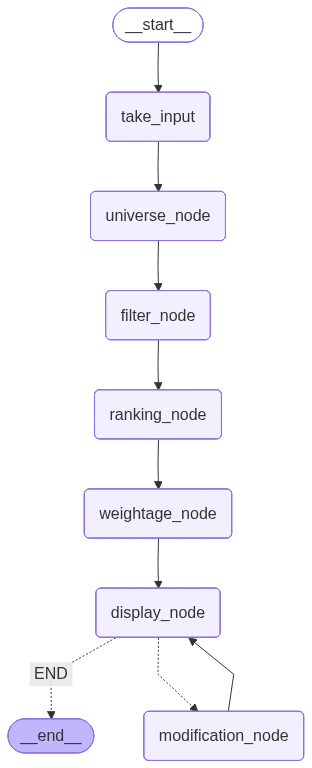

In [12]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles
display(
  Image(
      app.get_graph().draw_mermaid_png()
  )
)


In [13]:
app = create_workflow_graph()
app.invoke({"input": "", "enriched_input": "", "metrics": [], "universe": "",
            "filters": [], "ranking_metrics": [], "top_n": 0,
            "weight_type": "equal", "weight_metrics": [], "reasoning": {}})

🟢 Paste the strategy description here:
You Find undervalued large-cap Indian stocks with low PE ratio, strong earnings growth, and good dividend yield. I want a conservative, long-term strategy.
🔴 * Core thesis: The strategy exploits the market inefficiency of undervaluing large-cap Indian stocks with strong fundamentals, specifically targeting those with low price-to-earnings (P/E) ratios, high earnings growth, and attractive dividend yields. This approach aims to capitalize on the eventual revaluation of these stocks as their financial performance becomes more recognized by the market. The underlying assumption is that the market temporarily overlooks the true value of these companies.

* Target stocks: The strategy focuses on large-cap Indian stocks (assumed: market capitalization above $5 billion) across various sectors, prioritizing those with a history of stable operations and a strong track record of dividend payments. The companies should be listed on major Indian stock exchang

{'input': 'You Find undervalued large-cap Indian stocks with low PE ratio, strong earnings growth, and good dividend yield. I want a conservative, long-term strategy.',
 'enriched_input': "ORIGINAL:\n* Core thesis: The strategy exploits the market inefficiency of undervaluing large-cap Indian stocks with strong fundamentals, specifically targeting those with low price-to-earnings (P/E) ratios, high earnings growth, and attractive dividend yields. This approach aims to capitalize on the eventual revaluation of these stocks as their financial performance becomes more recognized by the market. The underlying assumption is that the market temporarily overlooks the true value of these companies.\n\n* Target stocks: The strategy focuses on large-cap Indian stocks (assumed: market capitalization above $5 billion) across various sectors, prioritizing those with a history of stable operations and a strong track record of dividend payments. The companies should be listed on major Indian stock ex